**Data Preparation**

In [52]:
import os
import time
import copy
import json
from pathlib import Path
from typing import Tuple, Dict, Any


import numpy as np
from PIL import Image


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models
import torch.nn.functional as F
import random


from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_recall_curve, auc
from sklearn.metrics import cohen_kappa_score
from scipy.stats import pearsonr

In [3]:
import os
import zipfile

# Path to your uploaded zip file in Colab
zip_path = "/content/DL_Assignment1_Dataset.zip"

# Extract it
extract_dir = "/content/data"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Now set CONFIG paths relative to the extracted folder
CONFIG = {
    "DATA_DIR": os.path.join(extract_dir, "images"),      # extracted folder with images
    "ANNOT_NPY": os.path.join(extract_dir, "annotations.npy"),  # extracted .npy file
    "BATCH_SIZE": 32,
    "NUM_EPOCHS": 30,
    "LR": 1e-4,
    "WEIGHT_DECAY": 1e-5,
    "NUM_WORKERS": 4,
    "DEVICE": "cuda" if torch.cuda.is_available() else "cpu",
    "OUTPUT_DIR": "/content/outputs",
    "VAL_SPLIT": 0.15,
    "RANDOM_SEED": 42,
    # Loss weights
    "CLASS_WEIGHT": 1.0,
    "REG_WEIGHT": 1.0,
}

os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)

print("Data directory:", CONFIG["DATA_DIR"])
print("Annotations file:", CONFIG["ANNOT_NPY"])


Data directory: /content/data/images
Annotations file: /content/data/annotations.npy


In [4]:
from google.colab import files
uploaded = files.upload()

Saving DL_Assignment1_Dataset.zip to DL_Assignment1_Dataset (1).zip


In [5]:
import zipfile, os

zip_path = "/content/DL_Assignment1_Dataset (1).zip"
extract_dir = "/content/data"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [6]:
CONFIG = {
    "DATA_DIR": os.path.join(extract_dir, "images"),
    "ANNOT_NPY": os.path.join(extract_dir, "annotations.npy"),
    "BATCH_SIZE": 32,
    "NUM_EPOCHS": 30,
    "LR": 1e-4,
    "WEIGHT_DECAY": 1e-5,
    "NUM_WORKERS": 4,
    "DEVICE": "cuda" if torch.cuda.is_available() else "cpu",
    "OUTPUT_DIR": "/content/outputs",
    "VAL_SPLIT": 0.15,
    "RANDOM_SEED": 42,
    "CLASS_WEIGHT": 1.0,
    "REG_WEIGHT": 1.0,
}

os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)

**Model Training**

In [7]:
# Run this whole cell in Colab
import os, glob, zipfile, numpy as np, traceback

print("Current working dir:", os.getcwd())
print("\nTop-level /content listing (first 40 entries):")
try:
    print(os.listdir('/content')[:40])
except Exception as e:
    print("cannot list /content:", e)

# Helpful candidate paths to inspect
cand_dirs = [
    "/content/data",
    "/content/data/Dataset",
    "/content/data/Dataset/Dataset",
    "/content/Dataset",
    "/content/dataset",
    "/content/drive",
    "/content/drive/MyDrive"
]
for d in cand_dirs:
    print("\n==> Checking:", d)
    if os.path.exists(d):
        try:
            print("  exists; sample contents:", os.listdir(d)[:20])
        except Exception as e:
            print("  exists but cannot list:", e)
    else:
        print("  NOT FOUND")

# Find .npy and .npz recursively under /content (should be quick)
npy_files = glob.glob('/content/**/*.npy', recursive=True)
npz_files = glob.glob('/content/**/*.npz', recursive=True)
zip_files = glob.glob('/content/**/*.zip', recursive=True)

print("\nFound .npy files:", npy_files)
print("Found .npz files:", npz_files)
print("Found .zip files:", zip_files)

# If you set annots_path earlier, show its existence
try:
    annots_path = CONFIG.get("ANNOT_NPY", None)
    print("\nCONFIG['ANNOT_NPY']:", annots_path)
except Exception:
    annots_path = None

if annots_path:
    print("Path exists?", os.path.exists(annots_path))
    if os.path.exists(annots_path):
        print("File size (bytes):", os.path.getsize(annots_path))
        print("Attempting to load (allow_pickle=True)...")
        try:
            arr = np.load(annots_path, allow_pickle=True)
            print("Loaded. length:", len(arr))
            print("Type of arr[0]:", type(arr[0]))
            print("arr[0] preview:", repr(arr[0])[:1000])
        except Exception as e:
            print("Error while loading the given path:")
            traceback.print_exc()
    else:
        print("The configured path does not exist. Will attempt to auto-detect below.")

# If no annots_path or it doesn't exist, auto-pick the first .npy found
if (not annots_path) or (not os.path.exists(annots_path)):
    if len(npy_files) > 0:
        candidate = npy_files[0]
        print("\nAuto-using first found .npy:", candidate)
        CONFIG["ANNOT_NPY"] = candidate
        annots_path = candidate
        try:
            arr = np.load(annots_path, allow_pickle=True)
            print("Loaded auto-detected file. len:", len(arr))
            print("Type of arr[0]:", type(arr[0]))
            print("arr[0] preview:", repr(arr[0])[:1000])
        except Exception:
            print("Failed to load the auto-detected .npy file:")
            traceback.print_exc()
    else:
        print("\nNo .npy files found under /content. If you uploaded a zip, try extracting it below (uncomment).")

# Optional: automatically extract the first zip found (uncomment to use)
# if zip_files:
#     z = zip_files[0]
#     print("\nExtracting", z, "to /content/data ...")
#     with zipfile.ZipFile(z, 'r') as zip_ref:
#         zip_ref.extractall('/content/data')
#     print("Extraction complete. Re-run the cell to re-check files.")


Current working dir: /content

Top-level /content listing (first 40 entries):
['.config', 'outputs', 'DL_Assignment1_Dataset.zip', 'data', 'DL_Assignment1_Dataset (1).zip', 'sample_data']

==> Checking: /content/data
  exists; sample contents: ['Dataset']

==> Checking: /content/data/Dataset
  exists; sample contents: ['Dataset']

==> Checking: /content/data/Dataset/Dataset
  exists; sample contents: ['annotations', 'images']

==> Checking: /content/Dataset
  NOT FOUND

==> Checking: /content/dataset
  NOT FOUND

==> Checking: /content/drive
  NOT FOUND

==> Checking: /content/drive/MyDrive
  NOT FOUND

Found .npy files: ['/content/data/Dataset/Dataset/annotations/5287_exp.npy', '/content/data/Dataset/Dataset/annotations/777_exp.npy', '/content/data/Dataset/Dataset/annotations/3949_aro.npy', '/content/data/Dataset/Dataset/annotations/2887_exp.npy', '/content/data/Dataset/Dataset/annotations/656_lnd.npy', '/content/data/Dataset/Dataset/annotations/739_exp.npy', '/content/data/Dataset/Da

Traceback (most recent call last):
  File "/tmp/ipython-input-3974698761.py", line 72, in <cell line: 0>
    print("Loaded auto-detected file. len:", len(arr))
                                             ^^^^^^^^
TypeError: len() of unsized object


In [8]:
import os, glob, zipfile, numpy as np, traceback

print("Current working dir:", os.getcwd())
print("\nTop-level /content listing (first 40 entries):")
try:
    print(os.listdir('/content')[:40])
except Exception as e:
    print("cannot list /content:", e)

# Helpful candidate paths to inspect
cand_dirs = [
    "/content/data",
    "/content/data/Dataset",
    "/content/data/Dataset/Dataset",
    "/content/Dataset",
    "/content/dataset",
    "/content/drive",
    "/content/drive/MyDrive"
]
for d in cand_dirs:
    print("\n==> Checking:", d)
    if os.path.exists(d):
        try:
            print("  exists; sample contents:", os.listdir(d)[:20])
        except Exception as e:
            print("  exists but cannot list:", e)
    else:
        print("  NOT FOUND")

# Find .npy and .npz recursively under /content (should be quick)
npy_files = glob.glob('/content/**/*.npy', recursive=True)
npz_files = glob.glob('/content/**/*.npz', recursive=True)
zip_files = glob.glob('/content/**/*.zip', recursive=True)

print("\nFound .npy files:", npy_files)
print("Found .npz files:", npz_files)
print("Found .zip files:", zip_files)

# If you set annots_path earlier, show its existence
try:
    annots_path = CONFIG.get("ANNOT_NPY", None)
    print("\nCONFIG['ANNOT_NPY']:", annots_path)
except Exception:
    annots_path = None

if annots_path:
    print("Path exists?", os.path.exists(annots_path))
    if os.path.exists(annots_path):
        print("File size (bytes):", os.path.getsize(annots_path))
        print("Attempting to load (allow_pickle=True)...")
        try:
            arr = np.load(annots_path, allow_pickle=True)
            print("Loaded. length:", len(arr))
            print("Type of arr[0]:", type(arr[0]))
            print("arr[0] preview:", repr(arr[0])[:1000])
        except Exception as e:
            print("Error while loading the given path:")
            traceback.print_exc()
    else:
        print("The configured path does not exist. Will attempt to auto-detect below.")

# If no annots_path or it doesn't exist, auto-pick the first .npy found
if (not annots_path) or (not os.path.exists(annots_path)):
    if len(npy_files) > 0:
        candidate = npy_files[0]
        print("\nAuto-using first found .npy:", candidate)
        CONFIG["ANNOT_NPY"] = candidate
        annots_path = candidate
        try:
            arr = np.load(annots_path, allow_pickle=True)
            print("Loaded auto-detected file. len:", len(arr))
            print("Type of arr[0]:", type(arr[0]))
            print("arr[0] preview:", repr(arr[0])[:1000])
        except Exception:
            print("Failed to load the auto-detected .npy file:")
            traceback.print_exc()
    else:
        print("\nNo .npy files found under /content. If you uploaded a zip, try extracting it below (uncomment).")

# Optional: automatically extract the first zip found (uncomment to use)
if zip_files:
    z = zip_files[0]
    print("\nExtracting", z, "to /content/data ...")
    with zipfile.ZipFile(z, 'r') as zip_ref:
        zip_ref.extractall('/content/data')
    print("Extraction complete. Re-run the cell to re-check files.")


Current working dir: /content

Top-level /content listing (first 40 entries):
['.config', 'outputs', 'DL_Assignment1_Dataset.zip', 'data', 'DL_Assignment1_Dataset (1).zip', 'sample_data']

==> Checking: /content/data
  exists; sample contents: ['Dataset']

==> Checking: /content/data/Dataset
  exists; sample contents: ['Dataset']

==> Checking: /content/data/Dataset/Dataset
  exists; sample contents: ['annotations', 'images']

==> Checking: /content/Dataset
  NOT FOUND

==> Checking: /content/dataset
  NOT FOUND

==> Checking: /content/drive
  NOT FOUND

==> Checking: /content/drive/MyDrive
  NOT FOUND

Found .npy files: ['/content/data/Dataset/Dataset/annotations/5287_exp.npy', '/content/data/Dataset/Dataset/annotations/777_exp.npy', '/content/data/Dataset/Dataset/annotations/3949_aro.npy', '/content/data/Dataset/Dataset/annotations/2887_exp.npy', '/content/data/Dataset/Dataset/annotations/656_lnd.npy', '/content/data/Dataset/Dataset/annotations/739_exp.npy', '/content/data/Dataset/Da

Traceback (most recent call last):
  File "/tmp/ipython-input-1728466295.py", line 54, in <cell line: 0>
    print("Loaded. length:", len(arr))
                             ^^^^^^^^
TypeError: len() of unsized object


Extraction complete. Re-run the cell to re-check files.


In [9]:
import numpy as np

annotations = np.load(CONFIG["ANNOT_NPY"], allow_pickle=True)

print("Type of annotations:", type(annotations))
print("Annotations repr:", repr(annotations)[:500])  # print first 500 chars


Type of annotations: <class 'numpy.ndarray'>
Annotations repr: array('1', dtype='<U1')


In [10]:
print("Shape:", annotations.shape)
print("Data type:", annotations.dtype)

Shape: ()
Data type: <U1


In [11]:
import os
print(os.listdir("/content/data/Dataset/Dataset"))

['annotations', 'images']


In [12]:
import os

ann_dir = "/content/data/Dataset/Dataset/annotations"
print(os.listdir(ann_dir))

['5287_exp.npy', '777_exp.npy', '3949_aro.npy', '2887_exp.npy', '656_lnd.npy', '739_exp.npy', '2473_exp.npy', '4829_exp.npy', '3241_aro.npy', '5378_lnd.npy', '692_val.npy', '2925_aro.npy', '664_val.npy', '2229_exp.npy', '4382_val.npy', '1991_lnd.npy', '2807_val.npy', '3402_exp.npy', '1993_exp.npy', '3534_lnd.npy', '507_val.npy', '1185_lnd.npy', '3774_val.npy', '3174_lnd.npy', '134_exp.npy', '2160_val.npy', '4603_lnd.npy', '2896_val.npy', '2084_val.npy', '5144_val.npy', '2576_aro.npy', '2946_val.npy', '1874_val.npy', '1937_lnd.npy', '5020_lnd.npy', '4731_val.npy', '4874_exp.npy', '5407_aro.npy', '4144_aro.npy', '4912_lnd.npy', '2359_aro.npy', '5255_val.npy', '2813_aro.npy', '1097_lnd.npy', '702_val.npy', '748_exp.npy', '1802_lnd.npy', '1804_exp.npy', '3886_aro.npy', '3555_exp.npy', '3878_val.npy', '3949_val.npy', '2924_aro.npy', '3812_lnd.npy', '2512_lnd.npy', '4457_aro.npy', '4390_aro.npy', '2045_lnd.npy', '2525_exp.npy', '3573_lnd.npy', '3486_exp.npy', '2242_exp.npy', '4558_exp.npy', 

In [13]:
import os

ann_dir = "/content/data/Dataset/Dataset/annotations"
files = os.listdir(ann_dir)

# Group files by type
exp_files = [f for f in files if f.endswith("_exp.npy")]
val_files = [f for f in files if f.endswith("_val.npy")]
aro_files = [f for f in files if f.endswith("_aro.npy")]
lnd_files = [f for f in files if f.endswith("_lnd.npy")]

print("Exp files:", len(exp_files))
print("Val files:", len(val_files))
print("Aro files:", len(aro_files))
print("Lnd files:", len(lnd_files))



Exp files: 3999
Val files: 3999
Aro files: 3999
Lnd files: 3999


In [14]:
def get_id(filename):
    return filename.split("_")[0]   # before first underscore

# Build dicts
exp_map = {get_id(f): os.path.join(ann_dir, f) for f in exp_files}
val_map = {get_id(f): os.path.join(ann_dir, f) for f in val_files}
aro_map = {get_id(f): os.path.join(ann_dir, f) for f in aro_files}
lnd_map = {get_id(f): os.path.join(ann_dir, f) for f in lnd_files}

# Common sample IDs (present in all 4)
sample_ids = set(exp_map.keys()) & set(val_map.keys()) & set(aro_map.keys()) & set(lnd_map.keys())
print("Total complete samples:", len(sample_ids))


Total complete samples: 3999


In [15]:
import numpy as np

sid = list(sample_ids)[0]
expression = int(np.load(exp_map[sid]))
valence = float(np.load(val_map[sid]))
arousal = float(np.load(aro_map[sid]))
landmarks = np.load(lnd_map[sid])

print("Sample ID:", sid)
print("Expression:", expression)
print("Valence:", valence)
print("Arousal:", arousal)
print("Landmarks shape:", landmarks.shape)


Sample ID: 1679
Expression: 2
Valence: -0.658149
Arousal: -0.183895
Landmarks shape: (136,)


In [16]:
img_dir = "/content/data/Dataset/Dataset/images"
print("First 10 images:", os.listdir(img_dir)[:10])

First 10 images: ['599.jpg', '2175.jpg', '4414.jpg', '2878.jpg', '4842.jpg', '1880.jpg', '148.jpg', '1921.jpg', '1145.jpg', '4480.jpg']


In [30]:
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

class AffectDataset(Dataset):
    def __init__(self, img_dir, ann_dir, transform=None):
        """
        Args:
            img_dir (str): Path to images folder
            ann_dir (str): Path to annotations folder (with *_exp.npy, *_val.npy, *_aro.npy, *_lnd.npy)
            transform (callable, optional): Transformations for images
        """
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.transform = transform

        # Collect sample IDs (intersection of exp, val, aro, lnd)
        exp_files = [f for f in os.listdir(ann_dir) if f.endswith("_exp.npy")]
        val_files = [f for f in os.listdir(ann_dir) if f.endswith("_val.npy")]
        aro_files = [f for f in os.listdir(ann_dir) if f.endswith("_aro.npy")]
        lnd_files = [f for f in os.listdir(ann_dir) if f.endswith("_lnd.npy")]

        def get_id(filename): return filename.split("_")[0]

        exp_ids = {get_id(f) for f in exp_files}
        val_ids = {get_id(f) for f in val_files}
        aro_ids = {get_id(f) for f in aro_files}
        lnd_ids = {get_id(f) for f in lnd_files}

        # Keep only samples present in all annotation types
        self.sample_ids = sorted(list(exp_ids & val_ids & aro_ids & lnd_ids))
        print(f"Total complete samples found: {len(self.sample_ids)}")

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sid = self.sample_ids[idx]

        # Image path
        img_path = os.path.join(self.img_dir, f"{sid}.jpg")
        if not os.path.exists(img_path):  # fallback to png
            img_path = os.path.join(self.img_dir, f"{sid}.png")

        # Load image
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Load annotations
        exp = int(np.load(os.path.join(self.ann_dir, f"{sid}_exp.npy")))
        val = float(np.load(os.path.join(self.ann_dir, f"{sid}_val.npy")))
        aro = float(np.load(os.path.join(self.ann_dir, f"{sid}_aro.npy")))
        lnd = np.load(os.path.join(self.ann_dir, f"{sid}_lnd.npy"))

        # Outputs
        target_class = exp
        target_reg = np.array([val, aro], dtype=np.float32)

        return image, target_class, target_reg, lnd


In [33]:
from torchvision import transforms
img_dir = "/content/data/Dataset/Dataset/images"
ann_dir = "/content/data/Dataset/Dataset/annotations" # Define transforms
train_transform = transforms.Compose([ transforms.Resize((224, 224)),
                                       transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) ])
dataset = AffectDataset(img_dir, ann_dir, transform=train_transform) # Test one sample
img, exp, reg, lnd = dataset[0]
print("Image tensor shape:", img.shape)
print("Expression label:", exp)
print("Valence, Arousal:", reg)
print("Landmarks shape:", lnd.shape)

Total complete samples found: 3999
Image tensor shape: torch.Size([3, 224, 224])
Expression label: 0
Valence, Arousal: [-0.176846  -0.0776398]
Landmarks shape: (136,)


In [19]:
from torch.utils.data import DataLoader, random_split

# Define train/val split
val_split = 0.15
val_size = int(len(dataset) * val_split)
train_size = len(dataset) - val_size

train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

print(f"Train samples: {len(train_set)}, Val samples: {len(val_set)}")


Train samples: 3400, Val samples: 599


In [20]:
# ===============================
# 3. Models (ResNet + VGG)
# ===============================
class MultiTaskResNet(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        base = models.resnet50(weights="IMAGENET1K_V1")
        feat_dim = base.fc.in_features
        base.fc = nn.Identity()
        self.encoder = base
        self.classifier = nn.Linear(feat_dim, num_classes)
        self.regressor = nn.Linear(feat_dim, 2)

    def forward(self, x):
        features = self.encoder(x)
        return self.classifier(features), self.regressor(features)


class MultiTaskVGG16(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        base = models.vgg16(weights="IMAGENET1K_V1")
        feat_dim = base.classifier[-1].in_features
        base.classifier = nn.Identity()
        self.encoder = base
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, num_classes)
        )
        self.regressor = nn.Sequential(
            nn.Linear(feat_dim, 128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, 2)
        )

    def forward(self, x):
        features = self.encoder(x)
        if features.ndim > 2:
            features = features.view(features.size(0), -1)
        return self.classifier(features), self.regressor(features)

In [43]:
# ===============================
# 4. Training Loop
# ===============================
def train_model(model, train_loader, val_loader, optimizer, criterion_class, criterion_reg, device, epochs=5):
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        # ---- Training ----
        for imgs, exp, reg, lnd in train_loader:
            imgs, exp, reg = imgs.to(device), exp.to(device), reg.to(device)

            optimizer.zero_grad()
            out_class, out_reg = model(imgs)

            loss_c = criterion_class(out_class, exp)
            loss_r = criterion_reg(out_reg, reg)
            loss = loss_c + loss_r

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # ---- Validation ----
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, exp, reg, lnd in val_loader:
                imgs, exp, reg = imgs.to(device), exp.to(device), reg.to(device)
                out_class, out_reg = model(imgs)
                val_loss += (criterion_class(out_class, exp) + criterion_reg(out_reg, reg)).item()

        avg_val_loss = val_loss / len(val_loader)

        # Save history
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")

    return history


def plot_history(history, title="Training Curves"):
    plt.plot(history["train_loss"], label="Train")
    plt.plot(history["val_loss"], label="Val")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()


In [48]:
# ===============================
# 5. Metrics
# ===============================
def rmse(y_true, y_pred): return np.sqrt(np.mean((y_true - y_pred) ** 2))
def corr(y_true, y_pred): return pearsonr(y_true, y_pred)[0]
def sagr(y_true, y_pred): return np.mean(np.sign(y_true) == np.sign(y_pred))
def ccc(y_true, y_pred):
    x_mean, y_mean = np.mean(y_pred), np.mean(y_true)
    cov = np.mean((y_pred - x_mean) * (y_true - y_mean))
    return (2 * cov) / (np.var(y_pred) + np.var(y_true) + (x_mean - y_mean) ** 2)

def krippendorffs_alpha(y_true, y_pred):
    n = len(y_true)
    Do = np.sum(y_true != y_pred) / n
    categories = np.unique(np.concatenate([y_true, y_pred]))
    p = [(np.sum(y_true == c) + np.sum(y_pred == c)) / (2 * n) for c in categories]
    De = 1 - np.sum(np.array(p) ** 2)
    return 1 - (Do / De if De != 0 else 0)

def classification_metrics(y_true, y_pred, y_prob):
    metrics = {}
    metrics["Accuracy"] = accuracy_score(y_true, y_pred)
    metrics["F1-Score"] = f1_score(y_true, y_pred, average="weighted")
    metrics["Cohen's Kappa"] = cohen_kappa_score(y_true, y_pred)
    try:
        y_true_bin = np.zeros((len(y_true), len(np.unique(y_true))))
        for i, label in enumerate(y_true): y_true_bin[i, label] = 1
        metrics["AUC"] = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
        precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), y_prob.ravel())
        metrics["AUC-PR"] = auc(recall, precision)
    except: metrics["AUC"], metrics["AUC-PR"] = np.nan, np.nan
    metrics["Krippendorff's Alpha"] = krippendorffs_alpha(np.array(y_true), np.array(y_pred))
    return metrics

def evaluate_model(model, loader, device):
    model.eval()
    y_true_cls, y_pred_cls, y_prob_cls = [], [], []
    y_true_val, y_pred_val, y_true_aro, y_pred_aro = [], [], [], []

    with torch.no_grad():
        for imgs, exp, reg, lnd in loader:   # <-- now 4 values
            imgs, exp, reg = imgs.to(device), exp.to(device), reg.to(device)
            out_class, out_reg = model(imgs)

            # Classification
            probs = F.softmax(out_class, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            y_true_cls.extend(exp.cpu().numpy())
            y_pred_cls.extend(preds)
            y_prob_cls.extend(probs)

            # Regression
            out_reg, reg = out_reg.cpu().numpy(), reg.cpu().numpy()
            y_true_val.extend(reg[:,0]); y_true_aro.extend(reg[:,1])
            y_pred_val.extend(out_reg[:,0]); y_pred_aro.extend(out_reg[:,1])

    cls_metrics = classification_metrics(np.array(y_true_cls), np.array(y_pred_cls), np.array(y_prob_cls))
    reg_metrics = {
        "Valence RMSE": rmse(np.array(y_true_val), np.array(y_pred_val)),
        "Valence CORR": corr(np.array(y_true_val), np.array(y_pred_val)),
        "Valence SAGR": sagr(np.array(y_true_val), np.array(y_pred_val)),
        "Valence CCC": ccc(np.array(y_true_val), np.array(y_pred_val)),
        "Arousal RMSE": rmse(np.array(y_true_aro), np.array(y_pred_aro)),
        "Arousal CORR": corr(np.array(y_true_aro), np.array(y_pred_aro)),
        "Arousal SAGR": sagr(np.array(y_true_aro), np.array(y_pred_aro)),
        "Arousal CCC": ccc(np.array(y_true_aro), np.array(y_pred_aro)),
    }
    return cls_metrics, reg_metrics


In [45]:
# ===============================
# 6. Visualization
# ===============================
def show_predictions(model, dataset, device, class_names):
    model.eval()
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    for ax in axes:
        idx = random.randint(0, len(dataset) - 1)
        img, exp, reg = dataset[idx]
        with torch.no_grad():
            out_class, out_reg = model(img.unsqueeze(0).to(device))
            probs = F.softmax(out_class, dim=1).cpu().numpy()[0]
            pred_class = np.argmax(probs)
            pred_reg = out_reg.cpu().numpy()[0]
        ax.imshow(np.transpose(img.numpy(), (1,2,0)))
        ax.axis("off")
        ax.set_title(f"GT: {class_names[exp]}\nPred: {class_names[pred_class]}\nV/A: {pred_reg.round(2)}", fontsize=10)
    plt.tight_layout(); plt.show()

Total complete samples found: 3999
Using subset of 1500 samples

==== Training ResNet50 ====
Epoch 1/5 | Train: 2.1269 | Val: 1.9501
Epoch 2/5 | Train: 1.4484 | Val: 1.9147
Epoch 3/5 | Train: 0.8543 | Val: 1.9350
Epoch 4/5 | Train: 0.4592 | Val: 1.9710
Epoch 5/5 | Train: 0.2702 | Val: 1.9156


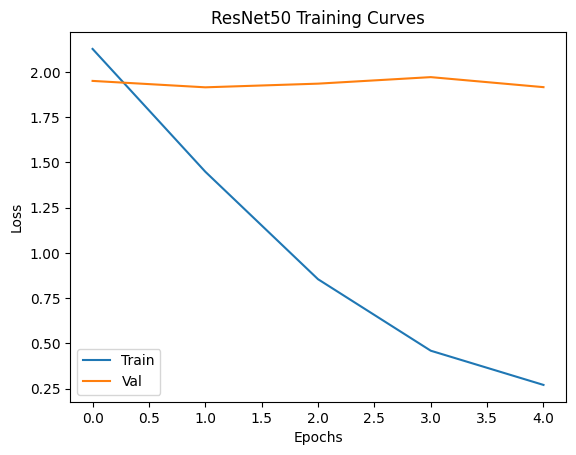


==== Training VGG16 ====
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:11<00:00, 49.5MB/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x25088 and 4096x256)

In [53]:
 #===============================
# 5. Main Run
# ===============================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    img_dir = "/content/data/Dataset/Dataset/images"
    ann_dir = "/content/data/Dataset/Dataset/annotations"

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])

    dataset = AffectDataset(img_dir, ann_dir, transform)

    # Use subset for speed
    subset_size = 1500
    dataset = torch.utils.data.Subset(dataset, range(subset_size))
    print(f"Using subset of {subset_size} samples")

    # Train/val split
    val_split = 0.15
    val_size = int(len(dataset) * val_split)
    train_size = len(dataset) - val_size
    train_set, val_set = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

    criterion_class = nn.CrossEntropyLoss()
    criterion_reg = nn.MSELoss()

    results = {}
    for model_name, model_class in [("ResNet50", MultiTaskResNet), ("VGG16", MultiTaskVGG16)]:
        print(f"\n==== Training {model_name} ====")
        model = model_class().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

        history = train_model(model, train_loader, val_loader, optimizer,
                              criterion_class, criterion_reg, device, epochs=5)

        plot_history(history, title=f"{model_name} Training Curves")

        cls_metrics, reg_metrics = evaluate_model(model, val_loader, device)
        results[model_name] = {"Classification": cls_metrics, "Regression": reg_metrics}

    # Comparison table
    df_cls = pd.DataFrame({m: results[m]["Classification"] for m in results}).T
    df_reg = pd.DataFrame({m: results[m]["Regression"] for m in results}).T

    print("\n=== Classification Comparison ===")
    print(df_cls)
    print("\n=== Regression Comparison ===")
    print(df_reg)

In [55]:
class MultiTaskVGG16(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        base = models.vgg16(weights="IMAGENET1K_V1")

        # keep only convolutional + pooling layers
        self.features = base.features
        self.avgpool = base.avgpool

        # Flattened feature dimension for 224x224 input
        feat_dim = 512 * 7 * 7   # = 25088

        # New heads (replace old classifier entirely)
        self.classifier = nn.Linear(feat_dim, num_classes)
        self.regressor = nn.Linear(feat_dim, 2)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)   # shape: (batch, 25088)
        out_class = self.classifier(x)
        out_reg = self.regressor(x)
        return out_class, out_reg


Total complete samples found: 3999
Using subset of 1500 samples

==== Training ResNet50 ====
Epoch 1/5 | Train: 2.1021 | Val: 1.9621
Epoch 2/5 | Train: 1.4450 | Val: 1.9909
Epoch 3/5 | Train: 0.8538 | Val: 1.8372
Epoch 4/5 | Train: 0.4358 | Val: 2.2680
Epoch 5/5 | Train: 0.2487 | Val: 2.4708


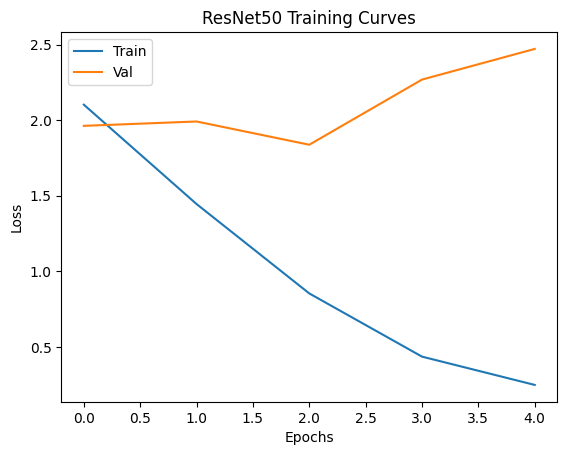


==== Training VGG16 ====


In [ ]:
# ===============================
# 5. Main Run
# ===============================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    img_dir = "/content/data/Dataset/Dataset/images"
    ann_dir = "/content/data/Dataset/Dataset/annotations"

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])

    dataset = AffectDataset(img_dir, ann_dir, transform)

    #  Use subset for speed (increase if GPU allows)
    subset_size = 1500
    dataset = torch.utils.data.Subset(dataset, range(subset_size))
    print(f"Using subset of {subset_size} samples")

    # Train/val split
    val_split = 0.15
    val_size = int(len(dataset) * val_split)
    train_size = len(dataset) - val_size
    train_set, val_set = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

    criterion_class = nn.CrossEntropyLoss()
    criterion_reg = nn.MSELoss()

    results = {}
    for model_name, model_class in [("ResNet50", MultiTaskResNet), ("VGG16", MultiTaskVGG16)]:
        print(f"\n==== Training {model_name} ====")
        model = model_class().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


        history = train_model(model, train_loader, val_loader, optimizer,
                              criterion_class, criterion_reg, device, epochs=5)


        plot_history(history, title=f"{model_name} Training Curves")

        # Evaluate
        cls_metrics, reg_metrics = evaluate_model(model, val_loader, device)
        results[model_name] = {"Classification": cls_metrics, "Regression": reg_metrics}

    # ===============================
    # 6. Results Comparison
    # ===============================
    df_cls = pd.DataFrame({m: results[m]["Classification"] for m in results}).T
    df_reg = pd.DataFrame({m: results[m]["Regression"] for m in results}).T

    print("\n=== Classification Comparison ===")
    print(df_cls.round(4))   # round for cleaner printing

    print("\n=== Regression Comparison ===")
    print(df_reg.round(4))
